In [565]:
import pandas as pd
import numpy as np

In [566]:
movies = pd.read_csv(r'C:\Users\ASUS\OneDrive\Documents\Movie Recommendation\tmdb_5000_movies.csv')
credits = pd.read_csv(r'C:\Users\ASUS\OneDrive\Documents\Movie Recommendation\tmdb_5000_credits.csv')

In [567]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [568]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


*Data Preprocessing*

Now we will be merging both, the movies and the credits

In [569]:
movies = movies.merge(credits, on='title')

In [570]:
columns_to_keep = ['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']
movies = movies[columns_to_keep]

In [571]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [572]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [573]:
movies.dropna(inplace = True)

In [574]:
movies.isnull().sum()

movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [575]:
movies.duplicated().sum()

np.int64(0)

In [576]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [577]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [578]:
# [{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]
#                                                           |
#                                                           |
#                                                           .
#                                 ['Action', 'Adventure', 'Fantasy', 'Science Fiction']

In [579]:
import ast

In [580]:
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):      # We used ast.literal_eval to convert the string to list
        L.append(i['name'])
    return L

In [581]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [582]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [583]:
movies['cast'][0]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [584]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [585]:
def convert3(obj):
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter != 3:                          # we will be taking only the first 3 cast people names(in real life names)
            L.append(i['name'])
            counter+=1
        else:
            break
    return L    

In [586]:
movies['cast'] =movies['cast'].apply(convert3)

In [587]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [588]:
def convert_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if(i['job'] == 'Director'):
            L.append(i['name'])
            break
    return L

In [589]:
movies['crew'] = movies['crew'].apply(convert_director)

In [590]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [591]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [592]:
# In genres, cast, crew and keywords we will deleting all the spaces between names as our model can get confused between Sam Worthington and Sam Mendes because both the names are Sam, thus  we are connecting it to their surnames. Same goes with genres like Science Fiction and Science
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ", "") for i in x])

In [593]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [594]:
# Now we will be adding all the keywords, cast, genres, crew into one new column called 'tags'
movies['tags'] = movies['overview'] + movies['genres'] + movies['cast'] + movies['crew'] + movies['keywords']

In [595]:
movies_new = movies.drop(columns=['overview', 'keywords', 'genres', 'cast', 'crew'], axis = 1)

In [596]:
movies_new['tags'] = movies_new['tags'].apply(lambda x: " ".join(x))
movies_new['tags'] = movies_new['tags'].apply(lambda x:x.lower())

In [597]:
movies_new.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


**Text Vectorization**

We will be using *Bag of Words*

also, we are removing all the english stop words

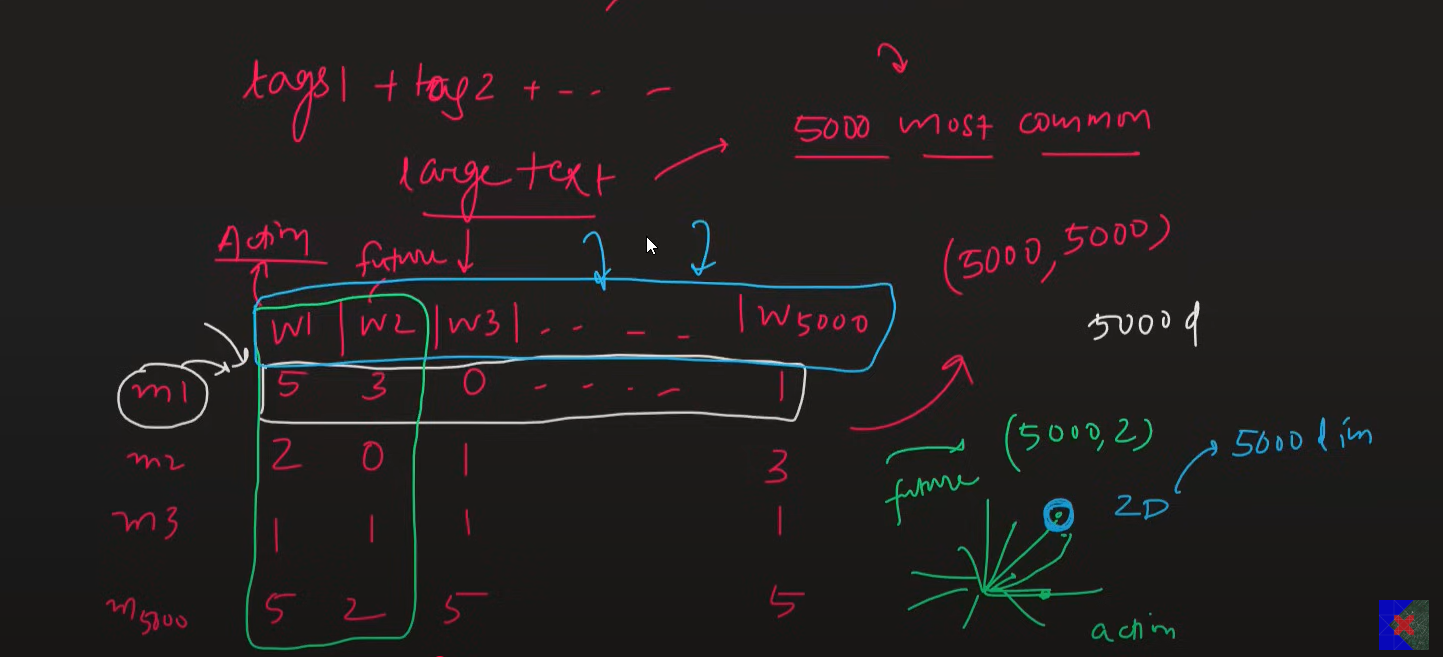

In [598]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words='english')

In [599]:
vectors = cv.fit_transform(movies_new['tags']).toarray()

In [600]:
vectors[0]      # This is the first movie

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [601]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [602]:
# Now we want Dance, Dancing, Dances to be only one word. Or Love, Loving, Loved to be only Love
# For this we will be using Stemming method provided by NLTK library

import nltk

In [603]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [604]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

In [605]:
# string = "I Loving Dancing"
# stem(string)

In [606]:
movies_new['tags'] = movies_new['tags'].apply(stem)

In [607]:
movies_new.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."


Now we will be using Cosine Similarity

In [608]:
from sklearn.metrics.pairwise import cosine_similarity

In [609]:
cosine_similarity(vectors)

array([[1.        , 0.08740748, 0.05827165, ..., 0.02418254, 0.02564946,
        0.        ],
       [0.08740748, 1.        , 0.06451613, ..., 0.02677398, 0.        ,
        0.        ],
       [0.05827165, 0.06451613, 1.        , ..., 0.02677398, 0.        ,
        0.        ],
       ...,
       [0.02418254, 0.02677398, 0.02677398, ..., 1.        , 0.07071068,
        0.04836508],
       [0.02564946, 0.        , 0.        , ..., 0.07071068, 1.        ,
        0.05129892],
       [0.        , 0.        , 0.        , ..., 0.04836508, 0.05129892,
        1.        ]], shape=(4806, 4806))

In [610]:
cosine_similarity(vectors).shape

(4806, 4806)

In [611]:
similarity = cosine_similarity(vectors)

In [612]:
similarity[0]    # Similarity of the first movie with every other movie

array([1.        , 0.08740748, 0.05827165, ..., 0.02418254, 0.02564946,
       0.        ], shape=(4806,))

In [613]:
movies_new['title'] == 'Batman Begins'

0       False
1       False
2       False
3       False
4       False
        ...  
4804    False
4805    False
4806    False
4807    False
4808    False
Name: title, Length: 4806, dtype: bool

In [614]:
movies_new[movies_new['title'] == 'Batman Begins'].index[0]

np.int64(119)

In [615]:
list(enumerate(similarity[0]))      # This is giving the cosine similarity of movie at index zero with every other movie who has indices 0, 1, 2, and so on.

[(0, np.float64(1.0000000000000002)),
 (1, np.float64(0.08740748201220976)),
 (2, np.float64(0.0582716546748065)),
 (3, np.float64(0.03823595564509363)),
 (4, np.float64(0.177343107178349)),
 (5, np.float64(0.11357771260606365)),
 (6, np.float64(0.019389168358237032)),
 (7, np.float64(0.1692777916923361)),
 (8, np.float64(0.06131393394849658)),
 (9, np.float64(0.07336739820667779)),
 (10, np.float64(0.11295649894498103)),
 (11, np.float64(0.07792865001991967)),
 (12, np.float64(0.09365858115816941)),
 (13, np.float64(0.04588314677411236)),
 (14, np.float64(0.10968169942141635)),
 (15, np.float64(0.04947706959952935)),
 (16, np.float64(0.07894736842105264)),
 (17, np.float64(0.1442149876003076)),
 (18, np.float64(0.10743376064838502)),
 (19, np.float64(0.08240856434303293)),
 (20, np.float64(0.055824219567359015)),
 (21, np.float64(0.08885233166386385)),
 (22, np.float64(0.0662266178532522)),
 (23, np.float64(0.09365858115816941)),
 (24, np.float64(0.0533380747062665)),
 (25, np.float64

In [616]:
sorted(list(enumerate(similarity[0])))  #This is getting sorted on the basis of movie indices (we want that to happen on the basis of  similarity). Also, similarity is getting sorted from LEAST to MOST similar, but we want MOST to LEAST similar.

[(0, np.float64(1.0000000000000002)),
 (1, np.float64(0.08740748201220976)),
 (2, np.float64(0.0582716546748065)),
 (3, np.float64(0.03823595564509363)),
 (4, np.float64(0.177343107178349)),
 (5, np.float64(0.11357771260606365)),
 (6, np.float64(0.019389168358237032)),
 (7, np.float64(0.1692777916923361)),
 (8, np.float64(0.06131393394849658)),
 (9, np.float64(0.07336739820667779)),
 (10, np.float64(0.11295649894498103)),
 (11, np.float64(0.07792865001991967)),
 (12, np.float64(0.09365858115816941)),
 (13, np.float64(0.04588314677411236)),
 (14, np.float64(0.10968169942141635)),
 (15, np.float64(0.04947706959952935)),
 (16, np.float64(0.07894736842105264)),
 (17, np.float64(0.1442149876003076)),
 (18, np.float64(0.10743376064838502)),
 (19, np.float64(0.08240856434303293)),
 (20, np.float64(0.055824219567359015)),
 (21, np.float64(0.08885233166386385)),
 (22, np.float64(0.0662266178532522)),
 (23, np.float64(0.09365858115816941)),
 (24, np.float64(0.0533380747062665)),
 (25, np.float64

In [617]:
# Thus we will sort on the basis of Similarity and also reverse it because we want the best match (i.e the greatest value) to come first.

sorted(list(enumerate(similarity[0])), reverse = True, key=lambda x:x[1])      # The key specifies what desired position to work on.

[(0, np.float64(1.0000000000000002)),
 (539, np.float64(0.25038669783359574)),
 (1192, np.float64(0.24779731389167606)),
 (507, np.float64(0.24283093212859141)),
 (260, np.float64(0.2409900932515112)),
 (1214, np.float64(0.23939494881986934)),
 (1916, np.float64(0.233785950059759)),
 (582, np.float64(0.23174488732966075)),
 (1202, np.float64(0.23084512921915967)),
 (2405, np.float64(0.23084512921915967)),
 (3728, np.float64(0.2294157338705618)),
 (1440, np.float64(0.21677749238103003)),
 (322, np.float64(0.21629522817435)),
 (74, np.float64(0.21526419295572297)),
 (3606, np.float64(0.21486752129677)),
 (83, np.float64(0.21296183592613546)),
 (61, np.float64(0.21239769762143662)),
 (4190, np.float64(0.21239769762143662)),
 (1533, np.float64(0.2108663315950723)),
 (2329, np.float64(0.20857039859669468)),
 (47, np.float64(0.20770324619863198)),
 (495, np.float64(0.20751433915982237)),
 (942, np.float64(0.20395079136182276)),
 (972, np.float64(0.20395079136182276)),
 (466, np.float64(0.202

In [618]:
# def recommend(movie):
#     movie_index = movies_new[movies_new['title'] == movie].index[0]
#     distances = similarity[movie_index]           # Dont assume distance as 1 - Similarity, it represents similarity only.

#     movies_list = sorted(list(enumerate(distances)), reverse=True, key = lambda x:x[1])[1:6]        #[1:6] --> First 5 elements

#     for i in movies_list:
#         print(i[0])

# This code will give the index of the recommended movies, but we want the names

In [619]:
def recommend(movie):
    movie_index = movies_new[movies_new['title'] == movie].index[0]   # This gives the index of the movie which user gave input
    distances = similarity[movie_index]           # Dont assume distance as 1 - Similarity, it represents similarity only.

    movies_list = sorted(list(enumerate(distances)), reverse=True, key = lambda x:x[1])[1:6]        #[1:6] --> First 5 elements

    for i in movies_list:
        print(movies_new.iloc[i[0]].title)

In [620]:
recommend('Avatar')

Titan A.E.
Small Soldiers
Independence Day
Ender's Game
Aliens vs Predator: Requiem


In [621]:
recommend('Batman Begins')

The Dark Knight
The Dark Knight Rises
Batman
Batman
Batman & Robin


In [627]:
recommend("Ghost Rider")

Ghost Rider: Spirit of Vengeance
Jackass: The Movie
The Outsiders
On the Waterfront
Jackass Number Two


In [ ]:
recommend("Spider-Man 3")

Spider-Man 2
Spider-Man
The Amazing Spider-Man 2
The Amazing Spider-Man
Arachnophobia


In [630]:
recommend("The Avengers")

Avengers: Age of Ultron
Captain America: Civil War
Iron Man 3
Captain America: The First Avenger
Iron Man


In [631]:
import pickle

In [633]:
pickle.dump(movies_new.to_dict(), open('movies_dict.pkl', 'wb'))

In [634]:
pickle.dump(similarity, open('similarity.pkl', 'wb'))